In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

# Cấu hình giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16})

In [2]:
# Định nghĩa đường dẫn gốc tới tập dữ liệu trên Kaggle
DATASET_DIR = "/kaggle/input/datasets/tienthanhf/dog-breeds-indentification"

# Kiểm tra sự tồn tại của thư mục gốc
if os.path.exists(DATASET_DIR):
    all_folders = sorted([f for f in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, f))])
    print(f"Đường dẫn hợp lệ!")
    print(f"Tổng số thư mục con tìm thấy (Số lớp): {len(all_folders)}")
else:
    print(f"Đường dẫn không tồn tại. Vui lòng kiểm tra lại cấu hình!")

Đường dẫn hợp lệ!
Tổng số thư mục con tìm thấy (Số lớp): 120


In [3]:
# Quét toàn bộ thư mục để đếm số lượng ảnh của từng giống chó
breed_raw_names = []
breed_clean_names = []
image_counts = []
total_images = 0

for folder in all_folders:
    folder_path = os.path.join(DATASET_DIR, folder)
    # Lấy danh sách các file ảnh hợp lệ
    images = [img for img in os.listdir(folder_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    num_images = len(images)
    
    # Xử lý tên thư mục thành tên giống chó chuẩn (ví dụ: 'n02085620-Chihuahua' -> 'Chihuahua')
    clean_name = folder.split("-")[-1].replace("_", " ").title()
    
    breed_raw_names.append(folder)
    breed_clean_names.append(clean_name)
    image_counts.append(num_images)
    total_images += num_images

# Tạo DataFrame tổng hợp dữ liệu thống kê
df_stats = pd.DataFrame({
    'Raw_Folder': breed_raw_names,
    'Breed_Name': breed_clean_names,
    'Image_Count': image_counts
}).sort_values(by='Image_Count', ascending=False).reset_index(drop=True)

print(f"=== TỔNG QUAN SỐ LIỆU TẬP DỮ LIỆU ===")
print(f" Tổng số lượng hình ảnh toàn bộ bộ dữ liệu: {total_images} ảnh")
print(f" Số lượng ảnh trung bình trên mỗi lớp: {df_stats['Image_Count'].mean():.2f} ảnh")
print(f" Giống chó có nhiều ảnh nhất: '{df_stats.iloc[0]['Breed_Name']}' ({df_stats.iloc[0]['Image_Count']} ảnh)")
print(f" Giống chó có ít ảnh nhất: '{df_stats.iloc[-1]['Breed_Name']}' ({df_stats.iloc[-1]['Image_Count']} ảnh)")

=== TỔNG QUAN SỐ LIỆU TẬP DỮ LIỆU ===
 Tổng số lượng hình ảnh toàn bộ bộ dữ liệu: 20580 ảnh
 Số lượng ảnh trung bình trên mỗi lớp: 171.50 ảnh
 Giống chó có nhiều ảnh nhất: 'Maltese Dog' (252 ảnh)
 Giống chó có ít ảnh nhất: 'Redbone' (148 ảnh)


In [9]:
df_all_breeds = df_stats[['Breed_Name', 'Image_Count']].sort_values(by='Breed_Name').reset_index(drop=True)
df_all_breeds.index = df_all_breeds.index + 1  # Đánh số thứ tự từ 1

print(f"=== DANH SÁCH TOÀN BỘ 120 GIỐNG CHÓ TRONG DATASET ===")

pd.set_option('display.max_rows', 120)
display(df_all_breeds)

=== DANH SÁCH TOÀN BỘ 120 GIỐNG CHÓ TRONG DATASET ===


,Breed_Name,Image_Count
1,Affenpinscher,150
2,Afghan Hound,239
3,African Hunting Dog,169
4,Airedale,202
5,American Staffordshire Terrier,164
6,Appenzeller,151
7,Australian Terrier,196
8,Basenji,209
9,Basset,175
10,Beagle,195


/tmp/ipykernel_58/3313895279.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='Image_Count', y='Breed_Name', data=df_stats.head(30), palette='crest_r')
/tmp/ipykernel_58/3313895279.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='Image_Count', y='Breed_Name', data=df_stats.tail(30), palette='flare_r')


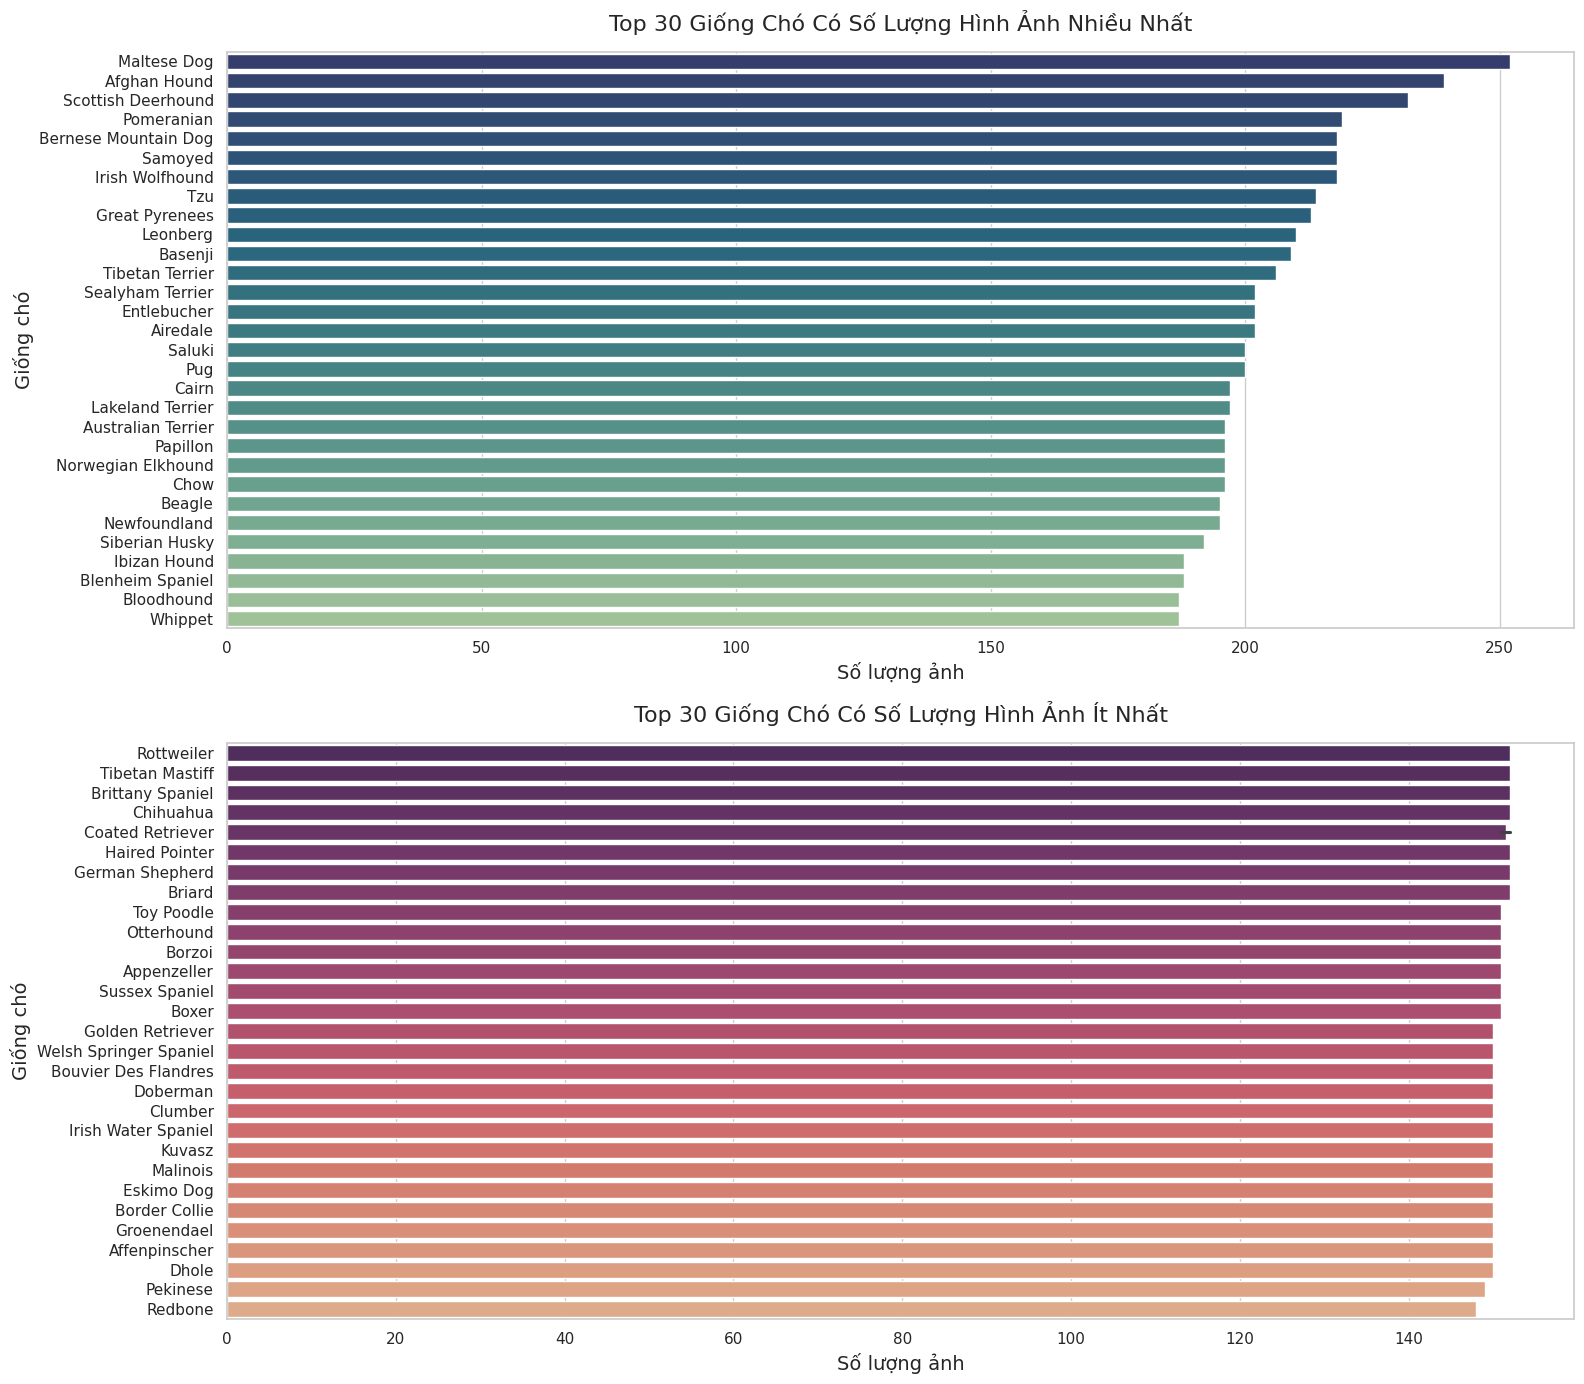

In [4]:
# Vẽ biểu đồ cột cho Top 30 giống chó có nhiều ảnh nhất và Bottom 30 ít ảnh nhất
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# Top 30 nhiều nhất
sns.barplot(ax=axes[0], x='Image_Count', y='Breed_Name', data=df_stats.head(30), palette='crest_r')
axes[0].set_title('Top 30 Giống Chó Có Số Lượng Hình Ảnh Nhiều Nhất', pad=15)
axes[0].set_xlabel('Số lượng ảnh')
axes[0].set_ylabel('Giống chó')

# Bottom 30 ít nhất
sns.barplot(ax=axes[1], x='Image_Count', y='Breed_Name', data=df_stats.tail(30), palette='flare_r')
axes[1].set_title('Top 30 Giống Chó Có Số Lượng Hình Ảnh Ít Nhất', pad=15)
axes[1].set_xlabel('Số lượng ảnh')
axes[1].set_ylabel('Giống chó')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# Tiến hành lấy mẫu (sampling) ngẫu nhiên 1000 ảnh từ dataset để khảo sát kích thước hình ảnh
sampled_widths = []
sampled_heights = []
all_image_paths = []

for folder in all_folders:
    folder_path = os.path.join(DATASET_DIR, folder)
    images = [os.path.join(folder_path, img) for img in os.listdir(folder_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    all_image_paths.extend(images)

# Chọn ngẫu nhiên 1000 ảnh
random.seed(42)
sampled_paths = random.sample(all_image_paths, min(1000, len(all_image_paths)))

for img_path in sampled_paths:
    with Image.open(img_path) as img:
        w, h = img.size
        sampled_widths.append(w)
        sampled_heights.append(h)

df_res = pd.DataFrame({'Width': sampled_widths, 'Height': sampled_heights})
df_res['Aspect_Ratio'] = df_res['Width'] / df_res['Height']

print(f"=== PHÂN TÍCH ĐỘ PHÂN GIẢI ẢNH (MẪU 1000 ẢNH) ===")
print(f" Chiều rộng (Width) trung bình: {df_res['Width'].mean():.1f} px (Min: {df_res['Width'].min()}, Max: {df_res['Width'].max()})")
print(f" Chiều cao (Height) trung bình: {df_res['Height'].mean():.1f} px (Min: {df_res['Height'].min()}, Max: {df_res['Height'].max()})")
print(f" Tỷ lệ khung hình (Aspect Ratio) trung bình: {df_res['Aspect_Ratio'].mean():.2f}")

=== PHÂN TÍCH ĐỘ PHÂN GIẢI ẢNH (MẪU 1000 ẢNH) ===
 Chiều rộng (Width) trung bình: 305.0 px (Min: 57, Max: 1431)
 Chiều cao (Height) trung bình: 315.7 px (Min: 76, Max: 1091)
 Tỷ lệ khung hình (Aspect Ratio) trung bình: 1.01


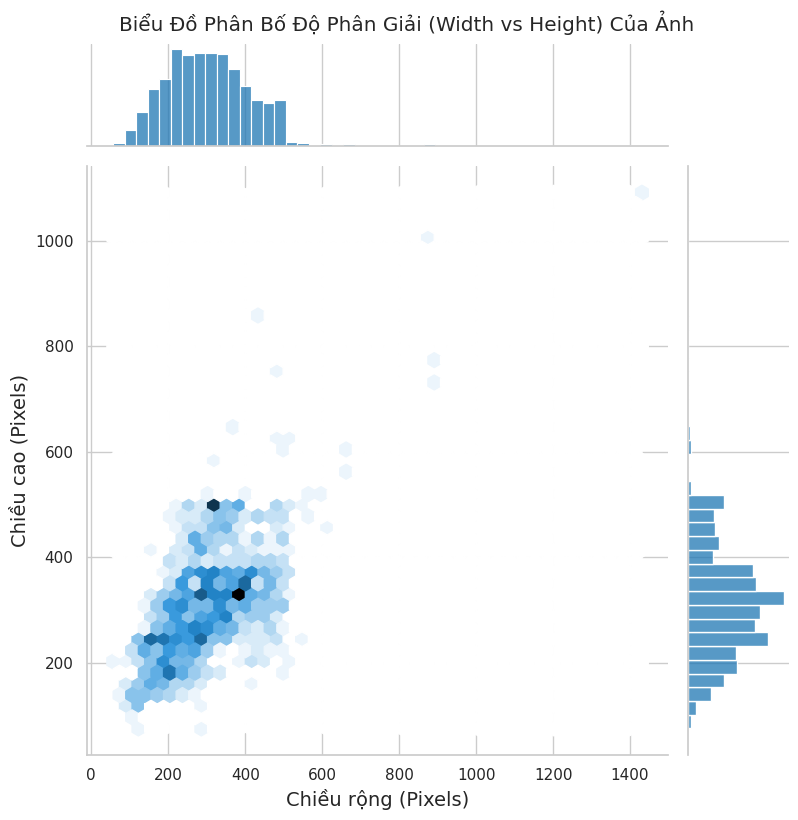

In [6]:
# Trực quan biểu đồ Jointplot thể hiện mối tương quan giữa Chiều rộng và Chiều cao của ảnh
joint_plot = sns.jointplot(data=df_res, x='Width', y='Height', kind='hex', color='#1f77b4', height=8)
joint_plot.fig.suptitle("Biểu Đồ Phân Bố Độ Phân Giải (Width vs Height) Của Ảnh", y=1.02)
joint_plot.set_axis_labels('Chiều rộng (Pixels)', 'Chiều cao (Pixels)')

plt.savefig('image_resolution_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

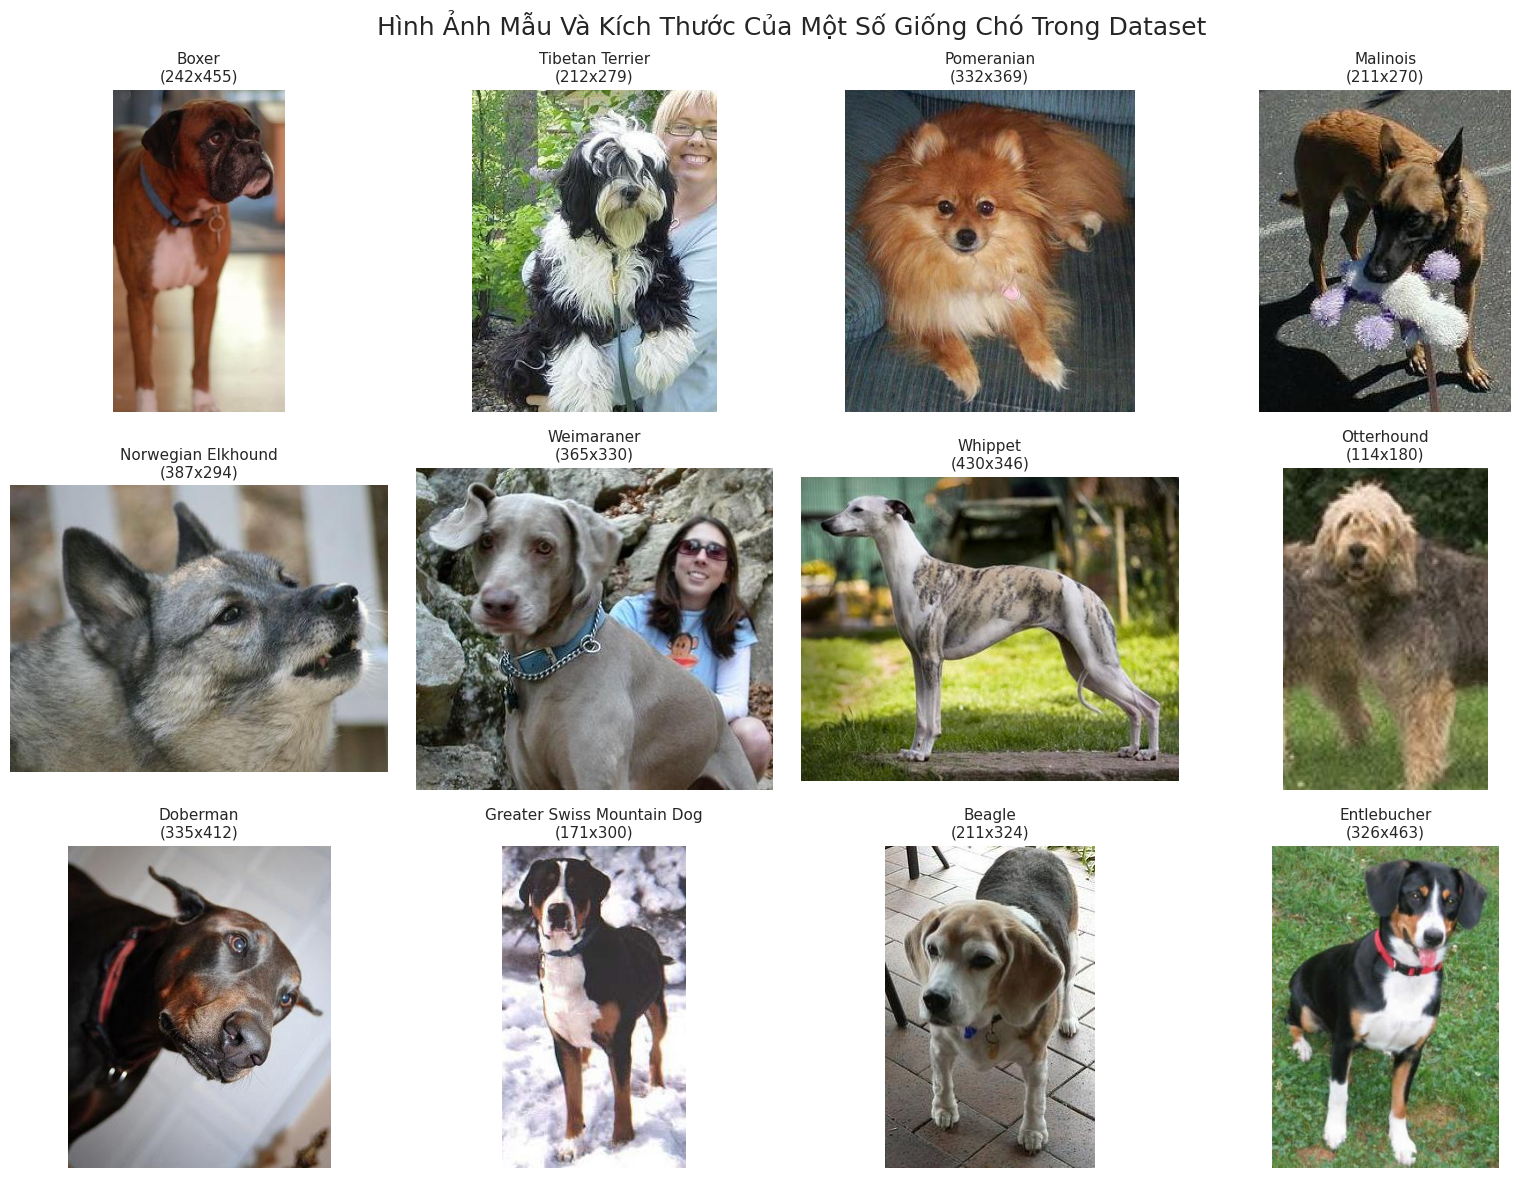

In [7]:
# Chọn ngẫu nhiên 12 giống chó khác nhau và hiển thị 1 ảnh đại diện của từng loại
random.seed(24)
selected_folders = random.sample(all_folders, 12)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, folder in enumerate(selected_folders):
    folder_path = os.path.join(DATASET_DIR, folder)
    images = [img for img in os.listdir(folder_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    img_name = random.choice(images)
    img_path = os.path.join(folder_path, img_name)
    
    clean_title = folder.split("-")[-1].replace("_", " ").title()
    
    with Image.open(img_path) as img:
        axes[i].imshow(img)
        axes[i].set_title(f"{clean_title}\n({img.size[0]}x{img.size[1]})", fontsize=11)
        axes[i].axis('off')

plt.suptitle("Hình Ảnh Mẫu Và Kích Thước Của Một Số Giống Chó Trong Dataset", fontsize=18, y=0.98)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# In ra các kết luận định lượng phục vụ trực tiếp cho việc viết báo cáo lý thuyết
print("=== KẾT LUẬN ===")
print("1. Sự cân bằng dữ liệu: Tập dữ liệu Stanford Dogs phân bố tương đối đồng đều (không bị mất cân bằng nghiêm trọng).")
print("   Do đó, sử dụng hàm Loss tiêu chuẩn (Cross-Entropy với Label Smoothing) là phù hợp.")
print("2. Biến động kích thước: Độ phân giải của ảnh cực kỳ không đồng nhất (ảnh lớn đạt >1000px, ảnh nhỏ chỉ khoảng ~150px).")
print("   Vì vậy, quy trình Transform bắt buộc phải áp dụng Resize về (224, 224) hoặc (384, 384) để quy chuẩn hóa đầu vào.")
print("3. Thách thức Fine-grained: Qua việc trực quan hóa hình ảnh mẫu, đối tượng (con chó) có bối cảnh nền phức tạp")
print("   (cỏ, bàn ghế, người nuôi), nhiều góc chụp nghiêng/thay đổi tư thế. Điều này minh chứng cho sự cần thiết của")
print("   các kỹ thuật Augmentation mạnh như ColorJitter, RandomRotation, và RandomErasing được sử dụng trong mô hình.")

=== KẾT LUẬN ===
1. Sự cân bằng dữ liệu: Tập dữ liệu Stanford Dogs phân bố tương đối đồng đều (không bị mất cân bằng nghiêm trọng).
   Do đó, sử dụng hàm Loss tiêu chuẩn (Cross-Entropy với Label Smoothing) là phù hợp.
2. Biến động kích thước: Độ phân giải của ảnh cực kỳ không đồng nhất (ảnh lớn đạt >1000px, ảnh nhỏ chỉ khoảng ~150px).
   Vì vậy, quy trình Transform bắt buộc phải áp dụng Resize về (224, 224) hoặc (384, 384) để quy chuẩn hóa đầu vào.
3. Thách thức Fine-grained: Qua việc trực quan hóa hình ảnh mẫu, đối tượng (con chó) có bối cảnh nền phức tạp
   (cỏ, bàn ghế, người nuôi), nhiều góc chụp nghiêng/thay đổi tư thế. Điều này minh chứng cho sự cần thiết của
   các kỹ thuật Augmentation mạnh như ColorJitter, RandomRotation, và RandomErasing được sử dụng trong mô hình.


In [10]:
# Quét và kiểm tra xem có ảnh nào bị lỗi cấu trúc tệp hoặc sai hệ màu không
corrupted_files = []
invalid_channels = []

for img_path in all_image_paths:
    try:
        with Image.open(img_path) as img:
            img.verify() # Kiểm tra file có bị lỗi cấu trúc (corrupted) không
            
        # Mở lại để kiểm tra hệ màu (mode)
        with Image.open(img_path) as img:
            if img.mode != 'RGB':
                invalid_channels.append((img_path, img.mode))
    except Exception as e:
        corrupted_files.append((img_path, str(e)))

print(f"=== KẾT QUẢ KIỂM TRA TÍNH TOÀN VẸN DỮ LIỆU ===")
print(f" Số lượng ảnh bị lỗi cấu trúc (Corrupted): {len(corrupted_files)}")
if len(corrupted_files) > 0:
    for path, err in corrupted_files[:5]:
        print(f"   - Lỗi tại: {path} ({err})")

print(f" Số lượng ảnh không phải hệ màu RGB chuẩn: {len(invalid_channels)}")
if len(invalid_channels) > 0:
    for path, mode in invalid_channels[:5]:
        print(f"   - Ảnh hệ màu {mode}: {path}")

=== KẾT QUẢ KIỂM TRA TÍNH TOÀN VẸN DỮ LIỆU ===
 Số lượng ảnh bị lỗi cấu trúc (Corrupted): 0
 Số lượng ảnh không phải hệ màu RGB chuẩn: 0


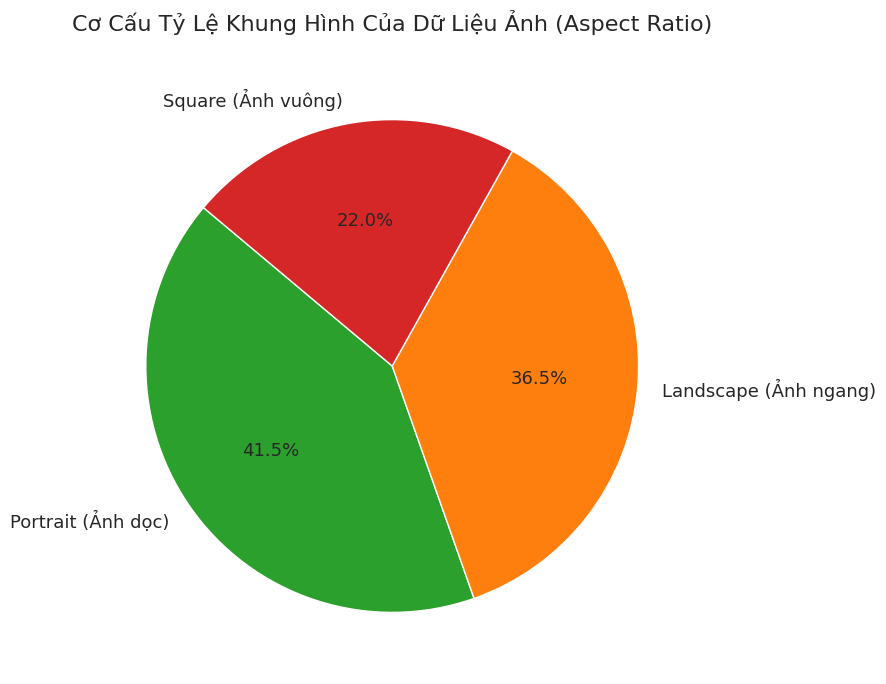

 Thống kê số lượng theo từng nhóm tỷ lệ:
Ratio_Category
Portrait (Ảnh dọc)       415
Landscape (Ảnh ngang)    365
Square (Ảnh vuông)       220
Name: count, dtype: int64


In [11]:
# Phân nhóm các tỷ lệ khung hình dựa trên mẫu 1000 ảnh đã lấy ở Cell 5
def categorize_aspect_ratio(ratio):
    if ratio > 1.1:
        return 'Landscape (Ảnh ngang)'
    elif ratio < 0.9:
        return 'Portrait (Ảnh dọc)'
    else:
        return 'Square (Ảnh vuông)'

df_res['Ratio_Category'] = df_res['Aspect_Ratio'].apply(categorize_aspect_ratio)
ratio_counts = df_res['Ratio_Category'].value_counts()

# Vẽ biểu đồ tròn thể hiện cơ cấu tỷ lệ ảnh
plt.figure(figsize=(8, 8))
plt.pie(ratio_counts, labels=ratio_counts.index, autopct='%1.1f%%', startangle=140, 
        colors=['#2ca02c', '#ff7f0e', '#d62728'], textprops={'fontsize': 13})
plt.title("Cơ Cấu Tỷ Lệ Khung Hình Của Dữ Liệu Ảnh (Aspect Ratio)", pad=20)
plt.savefig('aspect_ratio_pie_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Thống kê số lượng theo từng nhóm tỷ lệ:")
print(ratio_counts)